# Accord interannotateur

Total items: 500

Annotator count distribution:
500 items have 3 annotators

Using 500 items with 3 annotators each.
Total unités d'annotation (expériences) : 618
Total unités d'annotation : 618
Labels détectés : ['Différent', 'Réécriture']
Distribution : {'Différent': 935, 'Réécriture': 919}
Distribution annotateurs par unité : {3: 618}
Unités retenues (3 annotateurs) : 618

Fleiss' Kappa: 0.5447

Agreement Summary:


,Metric,Value
0,Total Items,500.0000
1,Items Used,500.0000
2,Annotators per Item,3.0000
3,Number of Classes,2.0000
4,Fleiss' Kappa,0.5447


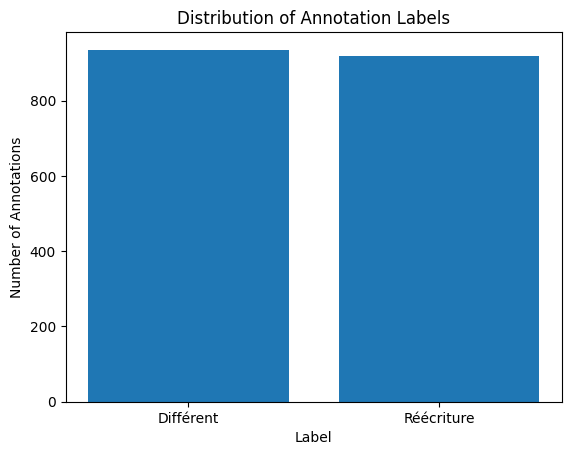

In [ ]:
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from torchmetrics.nominal import FleissKappa

# -----------------------------
# Load JSONL
# -----------------------------
file_path = "data_annot_1702_updated_small.jsonl"

data = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

print("Total items:", len(data))

# -----------------------------
# 1️⃣ Diagnostic Report
# -----------------------------
annotator_counts = [len(item["annotations"]) for item in data]
count_distribution = Counter(annotator_counts)

print("\nAnnotator count distribution:")
for k, v in sorted(count_distribution.items()):
    print(f"{v} items have {k} annotators")

expected_annotators = max(annotator_counts)

filtered_data = [
    item for item in data
    if len(item["annotations"]) == expected_annotators
]

print(f"\nUsing {len(filtered_data)} items with {expected_annotators} annotators each.")

# -----------------------------
# 2️⃣ Extract labels
# -----------------------------
flat_items = []  # liste de dicts {exp_id, labels par annotateur}

for item in data:
    # Déterminer le nombre d'expériences (longueur de result)
    n_exp = len(item["annotations"][0]["result"])

    # Vérification de cohérence : tous les annotateurs ont annoté le même nombre d'expériences
    assert all(len(ann["result"]) == n_exp for ann in item["annotations"]), \
        f"Incohérence dans item {item['id']}"

    for exp_idx in range(n_exp):
        flat_items.append({
            "id": f"{item['id']}_exp{exp_idx}",
            "labels": [ann["result"][exp_idx] for ann in item["annotations"]]
        })

print(f"Total unités d'annotation (expériences) : {len(flat_items)}")

# -----------------------------
# 3️⃣ Build rating tensor (depuis flat_items)
# -----------------------------
all_labels = [label for item in flat_items for label in item["labels"]]
label_counts = Counter(all_labels)
labels = sorted(set(all_labels))
label_to_index = {label: i for i, label in enumerate(labels)}
num_classes = len(labels)

print(f"Total unités d'annotation : {len(flat_items)}")
print(f"Labels détectés : {labels}")
print(f"Distribution : {dict(label_counts)}")

# Filtrer les items avec le bon nombre d'annotateurs
n_annotators = Counter(len(item["labels"]) for item in flat_items)
print(f"Distribution annotateurs par unité : {dict(n_annotators)}")

target_n = max(n_annotators, key=n_annotators.get)
filtered_flat = [item for item in flat_items if len(item["labels"]) == target_n]
print(f"Unités retenues ({target_n} annotateurs) : {len(filtered_flat)}")

# Construire le tenseur (n_items, n_classes) — comptage par catégorie
ratings_counts = []
for item in filtered_flat:
    row = [0] * num_classes
    for label in item["labels"]:
        row[label_to_index[label]] += 1
    ratings_counts.append(row)

ratings_tensor = torch.tensor(ratings_counts)

# -----------------------------
# 4️⃣ Compute Fleiss Kappa
# -----------------------------
metric = FleissKappa(mode="counts")
kappa = metric(ratings_tensor)

print("\nFleiss' Kappa:", round(kappa.item(), 4))
# -----------------------------
# 5️⃣ Create Summary Table
# -----------------------------
summary_df = pd.DataFrame({
    "Metric": [
        "Total Items",
        "Items Used",
        "Annotators per Item",
        "Number of Classes",
        "Fleiss' Kappa"
    ],
    "Value": [
        len(data),
        len(filtered_data),
        expected_annotators,
        num_classes,
        round(kappa.item(), 4)
    ]
})

print("\nAgreement Summary:")
display(summary_df)

# -----------------------------
# 6️⃣ Plot Label Distribution
# -----------------------------
label_df = pd.DataFrame({
    "Label": list(label_counts.keys()),
    "Count": list(label_counts.values())
})

plt.figure()
plt.bar(label_df["Label"], label_df["Count"])
plt.xlabel("Label")
plt.ylabel("Number of Annotations")
plt.title("Distribution of Annotation Labels")
plt.show()


Total items: 500
Total unités d'annotation : 618

Kappa par paire :
  senior vs junior_2 : κ=0.3662 (207 items communs)
  senior vs junior_1 : κ=0.4980 (153 items communs)
  senior vs student_2 : κ=0.2815 (180 items communs)
  senior vs student_1 : κ=0.4826 (160 items communs)
  junior_2 vs junior_1 : κ=0.5964 (221 items communs)
  junior_2 vs student_2 : κ=0.6545 (155 items communs)
  junior_2 vs student_1 : κ=0.5844 (185 items communs)
  junior_1 vs student_2 : κ=0.6930 (166 items communs)
  junior_1 vs student_1 : κ=0.7848 (196 items communs)
  student_2 vs student_1 : κ=0.5929 (231 items communs)

Kappa moyen par paires : 0.5534


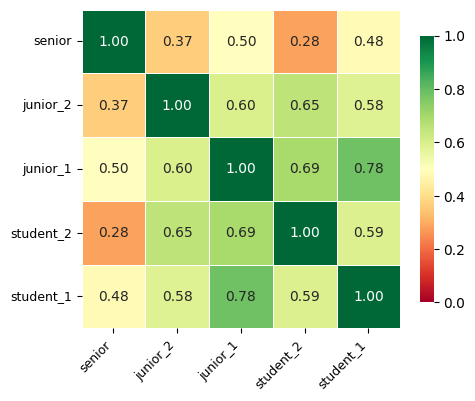

,Paire,Items communs,Cohen's κ,Interprétation
8,junior_1 / student_1,196,0.7848,Substantiel
7,junior_1 / student_2,166,0.6930,Substantiel
5,junior_2 / student_2,155,0.6545,Substantiel
4,junior_2 / junior_1,221,0.5964,Modéré
9,student_2 / student_1,231,0.5929,Modéré
6,junior_2 / student_1,185,0.5844,Modéré
1,senior / junior_1,153,0.4980,Modéré
3,senior / student_1,160,0.4826,Modéré
0,senior / junior_2,207,0.3662,Passable
2,senior / student_2,180,0.2815,Passable



Kappa moyen : 0.5534


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations
from sklearn.metrics import cohen_kappa_score

# -----------------------------
# Load JSONL
# -----------------------------
file_path = "data_annot_1702_updated_small.jsonl"

data = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

print("Total items:", len(data))

# -----------------------------
# Flatten par expérience en conservant l'identité des annotateurs
# -----------------------------
flat_items = []
for item in data:
    n_exp = len(item["annotations"][0]["result"])
    assert all(len(ann["result"]) == n_exp for ann in item["annotations"]), \
        f"Incohérence dans item {item['id']}"
    for exp_idx in range(n_exp):
        flat_items.append({
            "id": f"{item['id']}_exp{exp_idx}",
            "labels_by_annotator": {
                ann["completed_by"]["email"]: ann["result"][exp_idx]
                for ann in item["annotations"]
            }
        })

print(f"Total unités d'annotation : {len(flat_items)}")

# -----------------------------
# Anonymisation : email -> Annotateur [i]
# -----------------------------
all_emails = sorted({email for item in flat_items for email in item["labels_by_annotator"]})
email_to_anon = {email: censure[email] for i, email in enumerate(all_emails)}

annotators_anon = list(email_to_anon.values())

# -----------------------------
# Kappa de Cohen par paire
# -----------------------------
pairwise_kappas = {}
print("\nKappa par paire :")
for (e1, a1), (e2, a2) in combinations(email_to_anon.items(), 2):
    common_items = [
        item for item in flat_items
        if e1 in item["labels_by_annotator"] and e2 in item["labels_by_annotator"]
    ]
    if len(common_items) < 20:
        print(f"  {a1} vs {a2} : pas assez de co-annotations ({len(common_items)})")
        continue
    y1 = [item["labels_by_annotator"][e1] for item in common_items]
    y2 = [item["labels_by_annotator"][e2] for item in common_items]
    k = cohen_kappa_score(y1, y2)
    pairwise_kappas[(a1, a2)] = (k, len(common_items))
    print(f"  {a1} vs {a2} : κ={k:.4f} ({len(common_items)} items communs)")

mean_kappa = sum(k for k, _ in pairwise_kappas.values()) / len(pairwise_kappas)
print(f"\nKappa moyen par paires : {mean_kappa:.4f}")

# -----------------------------
# Heatmap des kappas par paire
# -----------------------------
kappa_matrix = pd.DataFrame(index=annotators_anon, columns=annotators_anon, dtype=float)

for (a1, a2), (k, _) in pairwise_kappas.items():
    kappa_matrix.loc[a1, a2] = k
    kappa_matrix.loc[a2, a1] = k

for a in annotators_anon:
    kappa_matrix.loc[a, a] = 1.0

n = len(annotators_anon)
f, ax = plt.subplots(figsize=(n, n))
sns.heatmap(kappa_matrix.astype(float), annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=0, vmax=1, linewidths=0.5, ax=ax, square=True,
            cbar_kws={"shrink": 0.6, "aspect": 20})  # ← ici

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()
f.savefig("CohenAgreement.pdf", bbox_inches='tight')
# -----------------------------
# Tableau récapitulatif
# -----------------------------
summary_rows = []
for (a1, a2), (k, n) in pairwise_kappas.items():
    summary_rows.append({
        "Paire": f"{a1} / {a2}",
        "Items communs": n,
        "Cohen's κ": round(k, 4),
        "Interprétation": (
            "Presque parfait" if k > 0.80 else
            "Substantiel" if k > 0.60 else
            "Modéré" if k > 0.40 else
            "Passable" if k > 0.20 else
            "Léger"
        )
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Cohen's κ", ascending=False)
display(summary_df)
print(f"\nKappa moyen : {mean_kappa:.4f}")